In [ ]:
!pip install catboost
#GENERAL
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
#PATH PROCESS
import os
import os.path
from pathlib import Path
import glob
#IMAGE PROCESS
from PIL import Image
from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import cv2
from keras.applications.vgg16 import preprocess_input, decode_predictions
#SCALER & TRANSFORMATION
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from keras import regularizers
from sklearn.preprocessing import LabelEncoder
#ACCURACY CONTROL
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
#OPTIMIZER
from keras.optimizers import RMSprop,Adam,Optimizer,Optimizer, SGD
#MODEL LAYERS
from tensorflow.keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization,MaxPooling2D,BatchNormalization,\
                        Permute, TimeDistributed, Bidirectional,GRU, SimpleRNN,\
LSTM, GlobalAveragePooling2D, SeparableConv2D, ZeroPadding2D, Convolution2D, ZeroPadding2D,Reshape, Conv2DTranspose, LeakyReLU, GaussianNoise
from keras import models
from keras import layers
import tensorflow as tf
from keras.applications import VGG16,VGG19,inception_v3
from keras import backend as K
from keras.utils import plot_model
from keras.datasets import mnist
import keras
#SKLEARN CLASSIFIER
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.linear_model import ElasticNet
from sklearn.linear_model import ElasticNetCV
#IGNORING WARNINGS
from warnings import filterwarnings
filterwarnings("ignore",category=DeprecationWarning)
filterwarnings("ignore", category=FutureWarning)
filterwarnings("ignore", category=UserWarning)


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"prushtithumar","key":"b78521facfaf6ea8b2c71b10f5bc0d8f"}'}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download tentotheminus9/gravity-spy-gravitational-waves

Dataset URL: https://www.kaggle.com/datasets/tentotheminus9/gravity-spy-gravitational-waves
License(s): Attribution 4.0 International (CC BY 4.0)
gravity-spy-gravitational-waves.zip: Skipping, found more recently modified local copy (use --force to force download)


In [ ]:
!unzip gravity-spy-gravitational-waves.zip -d gravity-spy-gravitational-waves

Streaming output truncated to the last 5000 lines.
  inflating: gravity-spy-gravitational-waves/train/train/Whistle/L1_jbSGPY9SuI_spectrogram_1.0.png  
  inflating: gravity-spy-gravitational-waves/train/train/Whistle/L1_jbSGPY9SuI_spectrogram_2.0.png  
  inflating: gravity-spy-gravitational-waves/train/train/Whistle/L1_jbSGPY9SuI_spectrogram_4.0.png  
  inflating: gravity-spy-gravitational-waves/train/train/Whistle/L1_jbxYeVDEAK_spectrogram_0.5.png  
  inflating: gravity-spy-gravitational-waves/train/train/Whistle/L1_jbxYeVDEAK_spectrogram_1.0.png  
  inflating: gravity-spy-gravitational-waves/train/train/Whistle/L1_jbxYeVDEAK_spectrogram_2.0.png  
  inflating: gravity-spy-gravitational-waves/train/train/Whistle/L1_jbxYeVDEAK_spectrogram_4.0.png  
  inflating: gravity-spy-gravitational-waves/train/train/Whistle/L1_jsK4vgBbeO_spectrogram_0.5.png  
  inflating: gravity-spy-gravitational-waves/train/train/Whistle/L1_jsK4vgBbeO_spectrogram_1.0.png  
  inflating: gravity-spy-gravitational-w

In [81]:
import os
print(os.listdir())

['.config', 'gravity-spy-gravitational-waves.zip', 'gravity-spy-gravitational-waves', 'gravitational-waves-project-ligo-prediction.ipynb', 'sample_data']


In [82]:
print(os.listdir("gravity-spy-gravitational-waves"))

['validation', 'test', 'train', 'trainingset_v1d1_metadata.csv']


In [83]:
print(os.listdir("gravity-spy-gravitational-waves/train")[:10])

['train']


In [84]:
from pathlib import Path

list(Path("gravity-spy-gravitational-waves/train").glob("*/*.png"))[:5]

[]

In [85]:
from pathlib import Path

Wave_Train_Data = Path("gravity-spy-gravitational-waves/train/train")
Wave_Test_Data = Path("gravity-spy-gravitational-waves/test/test")
Wave_Validation_Data = Path("gravity-spy-gravitational-waves/validation/validation")

In [86]:
Train_PNG_Path = list(Wave_Train_Data.glob(r"*/*.png"))
Test_PNG_Path = list(Wave_Test_Data.glob(r"*/*.png"))
Validation_PNG_Path = list(Wave_Validation_Data.glob(r"*/*.png"))

In [87]:
Train_PNG_Labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1],Train_PNG_Path))
Test_PNG_Labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1],Test_PNG_Path))
Validation_PNG_Labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1],Validation_PNG_Path))

In [88]:
Train_PNG_Path_Series = pd.Series(Train_PNG_Path,name="PNG").astype(str)
Test_PNG_Path_Series = pd.Series(Test_PNG_Path,name="PNG").astype(str)
Validation_PNG_Path_Series = pd.Series(Validation_PNG_Path,name="PNG").astype(str)

In [89]:
Train_PNG_Labels_Series = pd.Series(Train_PNG_Labels,name="CATEGORY")
Test_PNG_Labels_Series = pd.Series(Test_PNG_Labels,name="CATEGORY")
Validation_PNG_Labels_Series = pd.Series(Validation_PNG_Labels,name="CATEGORY")

In [90]:
Main_Train_Data = pd.concat([Train_PNG_Path_Series,Train_PNG_Labels_Series],axis=1)
Main_Test_Data = pd.concat([Test_PNG_Path_Series,Test_PNG_Labels_Series],axis=1)
Main_Validation_Data = pd.concat([Validation_PNG_Path_Series,Validation_PNG_Labels_Series],axis=1)

In [91]:
print(len(Main_Train_Data))

22348


In [92]:
Main_Train_Data = Main_Train_Data.sample(frac=1).reset_index(drop=True)
Main_Test_Data = Main_Test_Data.sample(frac=1).reset_index(drop=True)
Main_Validation_Data = Main_Validation_Data.sample(frac=1).reset_index(drop=True)

# IMAGE GENERATOR

In [93]:
Train_Generator = ImageDataGenerator(rescale=1./255,
                              zoom_range=0.3,
                              shear_range=0.3,
                              horizontal_flip=True,
                              vertical_flip=True,
                              fill_mode="nearest",
                               height_shift_range=0.2,
                              width_shift_range=0.2)

In [94]:
Val_Test_Generator = ImageDataGenerator(rescale=1./255)

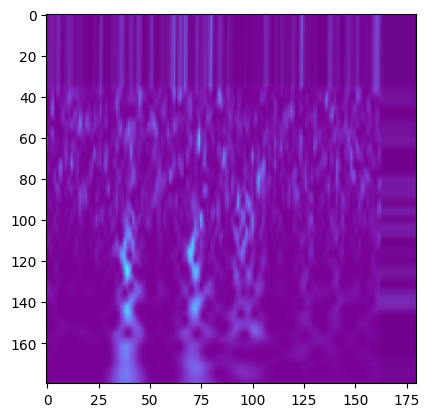

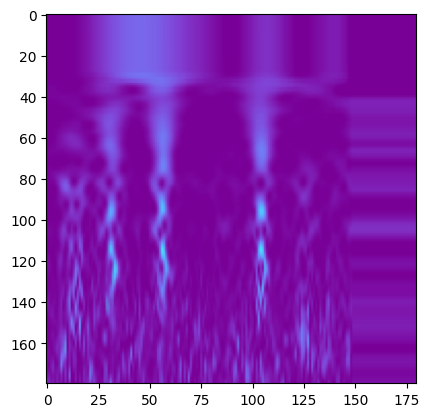

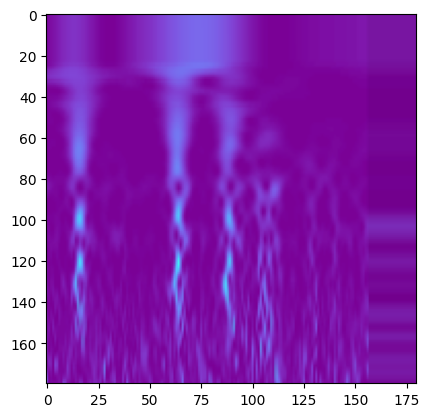

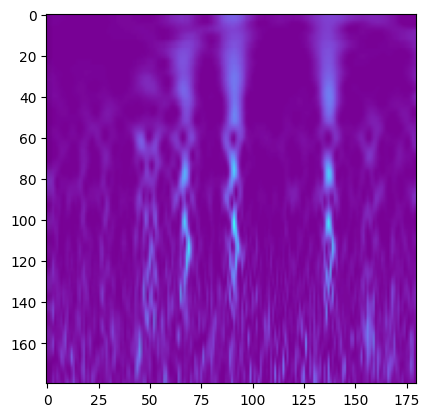

In [96]:
example_IMG = Main_Train_Data["PNG"][13945]
load_img = image.load_img(example_IMG,target_size=(180,180))
Array_Image = image.img_to_array(load_img)
Array_Image = Array_Image.reshape((1,) + Array_Image.shape)

i = 0
for batch in Train_Generator.flow(Array_Image,batch_size=1):
    plt.figure(i)
    IMG = plt.imshow(image.array_to_img(batch[0]))
    i += 1
    if i % 4 == 0:
        break
plt.show()

#### SPLITTING TRAIN, VALIDATION, TEST

In [97]:
Train_IMG_Set = Train_Generator.flow_from_dataframe(dataframe=Main_Train_Data,
                                                   x_col="PNG",
                                                   y_col="CATEGORY",
                                                   color_mode="rgb",
                                                   class_mode="categorical",
                                                   subset="training",
                                                    batch_size=32,
                                                   target_size=(180,180))

Found 22348 validated image filenames belonging to 22 classes.


In [98]:
Validation_IMG_Set = Val_Test_Generator.flow_from_dataframe(dataframe=Main_Validation_Data,
                                                        x_col="PNG",
                                                        y_col="CATEGORY",
                                                        color_mode="rgb",
                                                        class_mode="categorical",
                                                           batch_size=32,
                                                           target_size=(180,180))

Found 4800 validated image filenames belonging to 22 classes.


In [99]:
Test_IMG_Set = Val_Test_Generator.flow_from_dataframe(dataframe=Main_Test_Data,
                                                        x_col="PNG",
                                                        y_col="CATEGORY",
                                                        color_mode="rgb",
                                                        class_mode="categorical",
                                                           batch_size=32,
                                                           target_size=(180,180),
                                                     shuffle=False)

Found 4720 validated image filenames belonging to 22 classes.


In [100]:
for data_batch,label_batch in Train_IMG_Set:
    print("DATA SHAPE: ",data_batch.shape)
    print("LABEL SHAPE: ",label_batch.shape)
    break

DATA SHAPE:  (32, 180, 180, 3)
LABEL SHAPE:  (32, 22)


In [101]:
for data_batch,label_batch in Validation_IMG_Set:
    print("DATA SHAPE: ",data_batch.shape)
    print("LABEL SHAPE: ",label_batch.shape)
    break

DATA SHAPE:  (32, 180, 180, 3)
LABEL SHAPE:  (32, 22)


In [102]:
for data_batch,label_batch in Test_IMG_Set:
    print("DATA SHAPE: ",data_batch.shape)
    print("LABEL SHAPE: ",label_batch.shape)
    break

DATA SHAPE:  (32, 180, 180, 3)
LABEL SHAPE:  (32, 22)


In [103]:
print("TRAIN: ")
print(Train_IMG_Set.class_indices)
print(Train_IMG_Set.classes[0:5])
print(Train_IMG_Set.image_shape)
print("---"*20)
print("VALIDATION: ")
print(Validation_IMG_Set.class_indices)
print(Validation_IMG_Set.classes[0:5])
print(Validation_IMG_Set.image_shape)
print("---"*20)
print("TEST: ")
print(Test_IMG_Set.class_indices)
print(Test_IMG_Set.classes[0:5])
print(Test_IMG_Set.image_shape)

TRAIN: 
{'1080Lines': 0, '1400Ripples': 1, 'Air_Compressor': 2, 'Blip': 3, 'Chirp': 4, 'Extremely_Loud': 5, 'Helix': 6, 'Koi_Fish': 7, 'Light_Modulation': 8, 'Low_Frequency_Burst': 9, 'Low_Frequency_Lines': 10, 'No_Glitch': 11, 'None_of_the_Above': 12, 'Paired_Doves': 13, 'Power_Line': 14, 'Repeating_Blips': 15, 'Scattered_Light': 16, 'Scratchy': 17, 'Tomte': 18, 'Violin_Mode': 19, 'Wandering_Line': 20, 'Whistle': 21}
[15, 16, 16, 7, 7]
(180, 180, 3)
------------------------------------------------------------
VALIDATION: 
{'1080Lines': 0, '1400Ripples': 1, 'Air_Compressor': 2, 'Blip': 3, 'Chirp': 4, 'Extremely_Loud': 5, 'Helix': 6, 'Koi_Fish': 7, 'Light_Modulation': 8, 'Low_Frequency_Burst': 9, 'Low_Frequency_Lines': 10, 'No_Glitch': 11, 'None_of_the_Above': 12, 'Paired_Doves': 13, 'Power_Line': 14, 'Repeating_Blips': 15, 'Scattered_Light': 16, 'Scratchy': 17, 'Tomte': 18, 'Violin_Mode': 19, 'Wandering_Line': 20, 'Whistle': 21}
[17, 21, 9, 3, 3]
(180, 180, 3)
-------------------------

# CNN

In [104]:
Model = Sequential()

Model.add(Conv2D(24,(3,3),activation="relu",input_shape=(180,180,3)))
Model.add(BatchNormalization())
Model.add(MaxPooling2D((2,2),strides=2))

Model.add(Conv2D(64,(3,3),activation="relu",padding="same"))
Model.add(Dropout(0.3))
Model.add(MaxPooling2D((2,2),strides=2))

Model.add(Conv2D(64,(3,3),activation="relu",padding="same"))
Model.add(Dropout(0.3))
Model.add(MaxPooling2D((2,2),strides=2))

Model.add(Conv2D(128,(3,3),activation="relu",padding="same"))
Model.add(Conv2D(128,(3,3),activation="relu",padding="same"))
Model.add(Dropout(0.3))
Model.add(MaxPooling2D((2,2),strides=2))

Model.add(Conv2D(256,(3,3),activation="relu",padding="same"))
Model.add(Dropout(0.3))
Model.add(MaxPooling2D((2,2),strides=2))

Model.add(Flatten())
Model.add(Dense(2352,activation="relu"))
Model.add(Dropout(0.5))
Model.add(Dense(22,activation="softmax"))

In [105]:
Call_Back = tf.keras.callbacks.EarlyStopping(monitor="loss",patience=3,mode="min")

In [106]:
Model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [107]:
CNN_Model = Model.fit(Train_IMG_Set,validation_data=Validation_IMG_Set,callbacks=Call_Back,epochs=50)

Epoch 1/50
699/699 ━━━━━━━━━━━━━━━━━━━━ 432s 598ms/step - accuracy: 0.5926 - loss: 1.3469 - val_accuracy: 0.5448 - val_loss: 1.5634
Epoch 2/50
699/699 ━━━━━━━━━━━━━━━━━━━━ 388s 555ms/step - accuracy: 0.7463 - loss: 0.8146 - val_accuracy: 0.3915 - val_loss: 2.3046
Epoch 3/50
699/699 ━━━━━━━━━━━━━━━━━━━━ 382s 546ms/step - accuracy: 0.7843 - loss: 0.6966 - val_accuracy: 0.8150 - val_loss: 0.8460
Epoch 4/50
699/699 ━━━━━━━━━━━━━━━━━━━━ 380s 544ms/step - accuracy: 0.8038 - loss: 0.6307 - val_accuracy: 0.7621 - val_loss: 0.9206
Epoch 5/50
699/699 ━━━━━━━━━━━━━━━━━━━━ 380s 544ms/step - accuracy: 0.8142 - loss: 0.5995 - val_accuracy: 0.5692 - val_loss: 1.7849
Epoch 6/50
699/699 ━━━━━━━━━━━━━━━━━━━━ 379s 542ms/step - accuracy: 0.8211 - loss: 0.5673 - val_accuracy: 0.8400 - val_loss: 0.6641
Epoch 7/50
699/699 ━━━━━━━━━━━━━━━━━━━━ 384s 550ms/step - accuracy: 0.8302 - loss: 0.5495 - val_accuracy: 0.8219 - val_loss: 0.9059
Epoch 8/50
699/699 ━━━━━━━━━━━━━━━━━━━━ 382s 547ms/step - accuracy: 0.8416 -

In [109]:
Model_Results = Model.evaluate(Test_IMG_Set,verbose=False)
print("LOSS:  " + "%.4f" % Model_Results[0])
print("ACCURACY:  " + "%.2f" % Model_Results[1])

LOSS:  1.8417
ACCURACY:  0.60


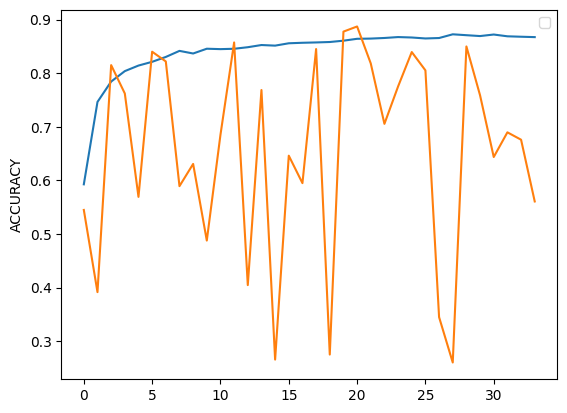

In [110]:
plt.plot(CNN_Model.history["accuracy"])
plt.plot(CNN_Model.history["val_accuracy"])
plt.ylabel("ACCURACY")
plt.legend()
plt.show()

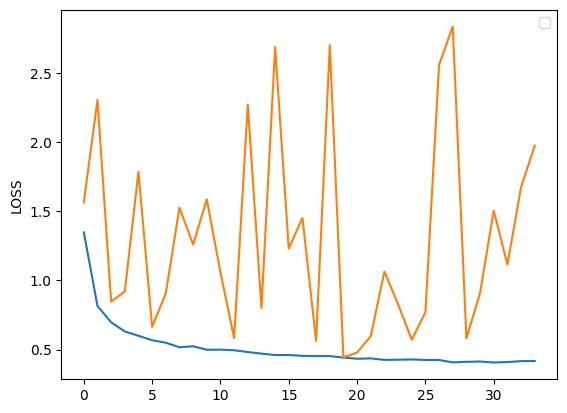

In [111]:
plt.plot(CNN_Model.history["loss"])
plt.plot(CNN_Model.history["val_loss"])
plt.ylabel("LOSS")
plt.legend()
plt.show()

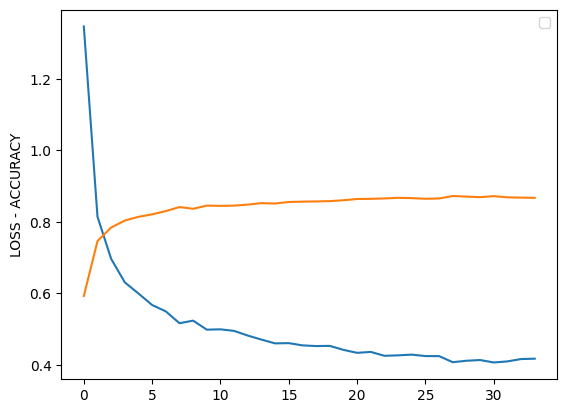

In [112]:
plt.plot(CNN_Model.history["loss"])
plt.plot(CNN_Model.history["accuracy"])
plt.ylabel("LOSS - ACCURACY")
plt.legend()
plt.show()

<Axes: >

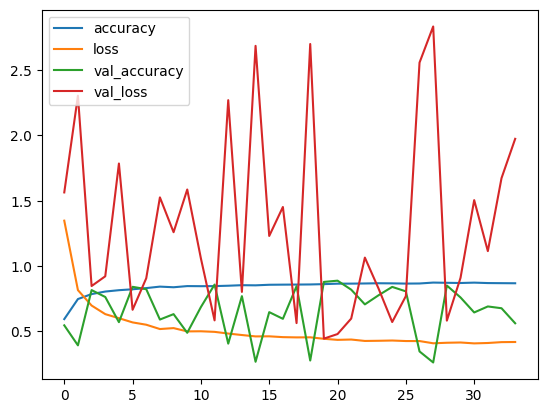

In [113]:
Dict_Summary = pd.DataFrame(CNN_Model.history)
Dict_Summary.plot()